## Demonstrate fast search and parameter estimation of MBHB 
- Data: TDC II-0.2, the TDI-combined version ([data](https://zenodo.org/records/15469724/files/0_2_MBHB_TDIXYZ.h5?download=1), [parameters](https://zenodo.org/records/15532090/files/0_2_MBHB_parameters.h5?download=1)) 
- Template: TDI-2.0 response of ``IMRPhenomD`` waveform (implemented in ``WF4PY``) 
- Method: $\mathcal{F}$-statistics, differential evolution optimization, nested sampling via ``NESSAI``      
This example represents an idealized scenario where there is only one bright MBHB in the data. 

In [1]:
# limit the thread used by numpy 
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"  

import numpy as np
from tqdm import tqdm
import pickle
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.optimize import differential_evolution
# import matplotlib
# matplotlib.rcParams['text.usetex'] = True
# matplotlib.rcParams['font.family'] = 'serif'

from Triangle.Constants import *
from Triangle.Orbit import * 
from Triangle.Noise import *
from Triangle.FFTTools import *
from Triangle.TDI import *
from Triangle.Data import * 

from Triangle_BBH.Waveform import * 
from Triangle_BBH.Response import *
from Triangle_BBH.Utils import *
from Triangle_BBH.Fisher import *

import multiprocessing
if __name__=='__main__':
    multiprocessing.set_start_method("fork")

PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


no cupy 
no cupy
No CuPy or GPU PhenomHM module.
has BBHx waveform


In [2]:
DATA_DIR = "/Users/taijidatacenter/workspace/TDCData/0_2_MBHB_TDIXYZ.h5"
PARAM_DIR = "/Users/taijidatacenter/workspace/TDCData/0_2_MBHB_parameters.h5"

ORBIT_DIR = "../../Triangle-Simulator/OrbitData/MicroSateOrbitEclipticTCB"

## Load data 

In [3]:
# the path of TDC data 
with h5py.File(DATA_DIR, "r") as h5file: 
    read_dict = read_dict_from_h5(h5file["/"])
    
# the path of parameters 
with h5py.File(PARAM_DIR, "r") as h5file: 
    injected_parameters = read_dict_from_h5(h5file["/"])
    
read_dict.keys(), injected_parameters.keys()

(dict_keys(['XYZ', 'time']),
 dict_keys(['chirp_mass', 'coalescence_phase', 'coalescence_time', 'inclination', 'latitude', 'longitude', 'luminosity_distance', 'mass_ratio', 'psi', 'spin_1z', 'spin_2z']))

### Combine AET and slice data near merger 
Assume that the merger time is roughly located (e.g. by whitening and examining the peak in time-domain data)

In [4]:
data_time = read_dict["time"]
A2_td, E2_td, _ = AETfromXYZ(read_dict["XYZ"]["X2"], read_dict["XYZ"]["Y2"], read_dict["XYZ"]["Z2"])
data_channels_td = -np.array([A2_td, E2_td]) # the convension of Michelson TDI-2.0 is different from Triangle-Simulator by a minus sign
channel_names = ["A2", "E2"] 

time_idx = np.where(np.abs(data_time/DAY - injected_parameters["coalescence_time"])<1.5)[0]
data_time = data_time[time_idx]
data_channels_td = data_channels_td[:, time_idx]

dt = data_time[1] - data_time[0]
Tobs = len(data_time) * dt 

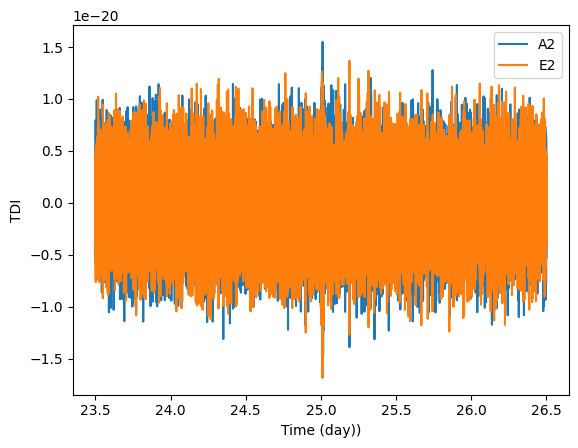

In [5]:
for i in range(len(data_channels_td)): 
    plt.plot(data_time/DAY, data_channels_td[i], label=channel_names[i])
plt.xlabel("Time (day))")
plt.ylabel("TDI")
plt.legend()

### Fourier transform 

In [6]:
data_channels_fd = [] 
for i in range(len(data_channels_td)): 
    ff, xf = FFT_window(
        data_array=data_channels_td[i], 
        fsample=1./dt, 
        window_type="tukey", 
        window_args_dict=dict(alpha=1000./Tobs)
    )
    data_channels_fd.append(xf) 
data_channels_fd = np.array(data_channels_fd) * np.exp(-TWOPI * 1.j * ff * data_time[0]) # shift to the "correct" time 
data_frequency = ff 

### Estimate noise PSD

In [7]:
ff, A2_PSD = PSD_window(
    data_array=A2_td[read_dict["time"]<data_time[0]], 
    fsample=1./dt, 
    window_type="hann", 
    nbin=20
)
ff, E2_PSD = PSD_window(
    data_array=E2_td[read_dict["time"]<data_time[0]], 
    fsample=1./dt, 
    window_type="hann", 
    nbin=20
)

psd_func_A2 = CubicSpline(ff, A2_PSD, extrapolate=True)
psd_func_E2 = CubicSpline(ff, E2_PSD, extrapolate=True)
psd_channels = np.array([
    psd_func_A2(data_frequency), 
    psd_func_E2(data_frequency)
])

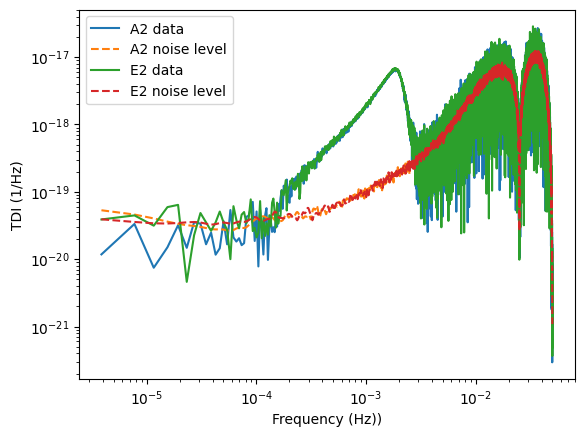

In [8]:
for i in range(len(data_channels_fd)): 
    plt.loglog(data_frequency, np.abs(data_channels_fd[i]), label=channel_names[i]+" data")
    plt.loglog(data_frequency, np.sqrt(psd_channels[i] * Tobs / 2.), linestyle="--", label=channel_names[i]+" noise level")
plt.xlabel("Frequency (Hz))")
plt.ylabel("TDI (1/Hz)")
plt.legend()

In [9]:
FMIN = 0.5e-4 
FMAX = 1e-2 
freq_idx = np.where((data_frequency>=FMIN)&(data_frequency<=FMAX))[0]
data_frequency = data_frequency[freq_idx]
data_channels_fd = data_channels_fd[:, freq_idx]
psd_channels = psd_channels[:, freq_idx]

## Models 

### waveform, response and noise

In [10]:
orbit = Orbit(OrbitDir=ORBIT_DIR)

# initialize  waveform generator 
WFG = WaveformGeneratorFRef(mode="primary")

# initialize response generator 
FDTDI = FDTDIResponseGeneratorFRef(orbit_class=orbit, waveform_generator=WFG)

# response settings 
response_kwargs_interp = dict(
    fmin=FMIN, 
    fmax=FMAX,
    fref=1e-3, 
    modes=[(2,2),], 
    tmin=data_time[0]/DAY,
    tmax=data_time[-1]/DAY, 
    tref_at_constellation=True, 
    TDIGeneration="2nd", # "1st" or "2nd"
    optimal_combination=True, # True for AET, False for XYZ 
    drop_T=True, 
    interpolation_method='cubic',
)

response_kwargs_direct = dict(
    fmin=FMIN, 
    fmax=FMAX,
    fref=1e-3, 
    modes=[(2,2),], 
    tmin=data_time[0]/DAY,
    tmax=data_time[-1]/DAY, 
    tref_at_constellation=True, 
    TDIGeneration="2nd", # "1st" or "2nd"
    optimal_combination=True, # True for AET, False for XYZ 
    drop_T=True, 
    interpolation_method=None,
)

# covariance matrix
CovMat = np.array([
    [psd_channels[0], np.zeros_like(data_frequency)],
    [np.zeros_like(data_frequency), psd_channels[1]],
]) / 4. * Tobs 

# inverse of covmatrix
InvCovMat = np.linalg.inv(np.transpose(CovMat, (2, 0, 1))) 

response_kwargs_interp, InvCovMat.shape 

({'fmin': 5e-05,
  'fmax': 0.01,
  'fref': 0.001,
  'modes': [(2, 2)],
  'tmin': 23.50011574074074,
  'tmax': 26.49988425925926,
  'tref_at_constellation': True,
  'TDIGeneration': '2nd',
  'optimal_combination': True,
  'drop_T': True,
  'interpolation_method': 'cubic'},
 (2579, 2, 2))

## Search high-likelihood parameters with $\mathcal{F}$-statistics

### set priors for the "intrinsic" parameters (dimension = 11 - 4)

In [11]:
lgMc_prior = [5., 7.]
q_prior = [0.01, 0.99]
s1_prior = [-0.99, 0.99]
s2_prior = [-0.99, 0.99]
tc_prior = [injected_parameters["coalescence_time"]-0.1, injected_parameters["coalescence_time"]+0.1] 
lam_prior = [0, TWOPI]
sinbeta_prior = [-1., 1.]
intrinsic_param_priors = np.array([
    lgMc_prior, 
    q_prior, 
    s1_prior, 
    s2_prior, 
    tc_prior, 
    lam_prior, 
    sinbeta_prior, 
])

### initialize $\mathcal{F}$-statitsitcs

In [12]:
Fstat = FstatisticsFref(
    response_generator=FDTDI, 
    frequency=data_frequency, 
    data=data_channels_fd, 
    invserse_covariance_matrix=InvCovMat, 
    response_parameters=response_kwargs_interp, 
    use_gpu=False, 
)

### search in prior 

In [13]:
def cost_function(norm_int_params):
    """   
        norm_int_params: shape (Nparams), normalized to (0, 1)
    """
    try: 
        int_params = norm_int_params * (intrinsic_param_priors[:, 1] - intrinsic_param_priors[:, 0]) + intrinsic_param_priors[:, 0] # (Nparams)
        params_in = Fstat.IntParamArr2ParamDict(int_params) # (Nparams) -> dictionary
        return -Fstat.calculate_Fstat(intrinsic_parameters=params_in) # float
    except np.linalg.LinAlgError:
        return np.infty 

n_dim_int = 7 
lower_bounds = np.zeros(n_dim_int) 
upper_bounds = np.ones(n_dim_int) 
bounds = np.array([lower_bounds, upper_bounds]).T # (Nparams, 2)

DE_result = differential_evolution(
    func=cost_function,
    bounds=bounds,
    x0=None,
    strategy='best1exp',
    maxiter=1000,
    popsize=5*n_dim_int,
    tol=1e-6,
    atol=1e-8,
    mutation=(0.4, 0.95),
    recombination=0.7,
    disp=False,
    polish=False,
    workers=-1, 
)

DE_result

/Users/taijidatacenter/miniconda3/envs/tri_env/lib/python3.9/site-packages/scipy/optimize/_differentialevolution.py:487: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,
/Users/taijidatacenter/miniconda3/envs/tri_env/lib/python3.9/site-packages/WF4Py/waveform_models/IMRPhenomHM.py:305: RuntimeWarning: invalid value encountered in sqrt
  fpeak = np.where(gamma2 >= 1.0, np.fabs(fring - (fdamp*gamma3)/gamma2), fring + (fdamp*(-1.0 + np.sqrt(1.0 - gamma2*gamma2))*gamma3)/gamma2)
/Users/taijidatacenter/miniconda3/envs/tri_env/lib/python3.9/site-packages/WF4Py/waveform_models/IMRPhenomHM.py:199: RuntimeWarning: invalid value encountered in sqrt
  fpeak = np.where(gamma2 >= 1.0, np.fabs(fring - (fdamp*gamma3)/gamma2), np.fabs(fring + (fdamp*(-1.0 + np.sqrt(1.0 - gamma2*gamma2))*gamma3)/gamma2))
/Users/taijidatacenter/miniconda3/envs/tri_env/lib/python3.9/site-packag

             message: Optimization terminated successfully.
             success: True
                 fun: -599733.6284956979
                   x: [ 7.381e-01  2.448e-01  6.985e-01  8.129e-01
                        4.881e-01  7.474e-01  5.920e-01]
                 nit: 153
                nfev: 37730
          population: [[ 7.381e-01  2.448e-01 ...  7.474e-01  5.920e-01]
                       [ 7.382e-01  2.448e-01 ...  7.389e-01  6.336e-01]
                       ...
                       [ 7.381e-01  2.450e-01 ...  7.547e-01  6.040e-01]
                       [ 7.381e-01  2.451e-01 ...  7.458e-01  6.108e-01]]
 population_energies: [-5.997e+05 -5.997e+05 ... -5.997e+05 -5.997e+05]

### Reconstruct other parameters and waveform 

In [14]:
searched_int_params = Fstat.IntParamArr2ParamDict(DE_result.x * (intrinsic_param_priors[:, 1] - intrinsic_param_priors[:, 0]) + intrinsic_param_priors[:, 0])
searched_a = Fstat.calculate_Fstat(
    intrinsic_parameters=searched_int_params, 
    return_a=True, 
) # (1, 4)
searched_ext_params = Fstat.a_to_extrinsic(searched_a)
searched_parameters = dict(searched_int_params, **searched_ext_params)

searched_wf = FDTDI.Response(
    searched_parameters, 
    data_frequency, 
    **response_kwargs_interp, 
)

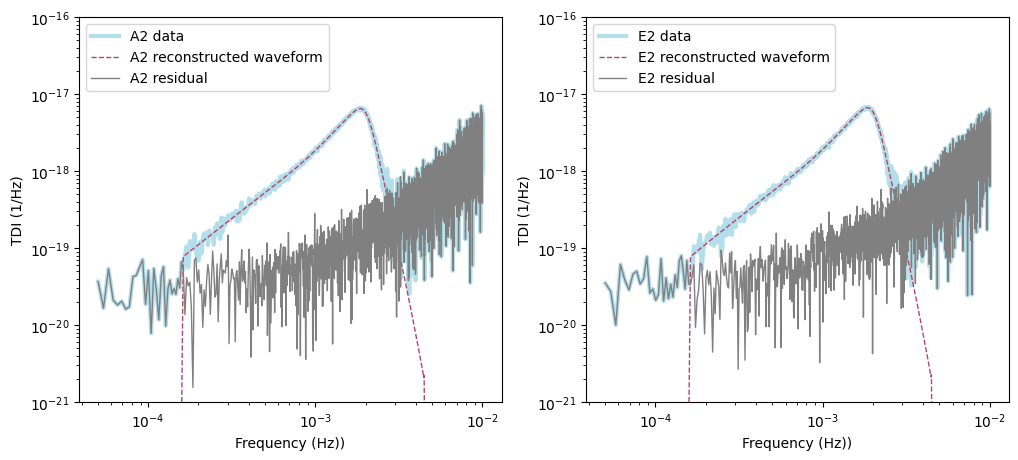

In [15]:
plt.figure(figsize=(12, 5))
for i in range(len(data_channels_fd)): 
    plt.subplot(121+i)
    plt.loglog(data_frequency, np.abs(data_channels_fd[i]), label=channel_names[i]+" data", color=BLUE, linewidth=3, alpha=0.5)
    plt.loglog(data_frequency, np.abs(searched_wf[i]), label=channel_names[i]+" reconstructed waveform", color=RED, linewidth=1, linestyle="--")
    plt.loglog(data_frequency, np.abs(data_channels_fd[i]-searched_wf[i]), label=channel_names[i]+" residual", color="grey", linewidth=1)
    plt.xlabel("Frequency (Hz))")
    plt.ylabel("TDI (1/Hz)")
    plt.legend(loc="upper left")
    plt.ylim(1e-21, 1e-16)

## Fisher analysis around the searched parameters 

In [16]:
def fisher_waveform_wrapper(param_dict, frequencies):
    res = FDTDI.Response(
        parameters=param_dict, 
        freqs=np.array(frequencies),  
        **response_kwargs_interp, 
    )
    return res

# set initial steps 
analyze_param_step_dict = {
    'chirp_mass': 10.,
    'mass_ratio': 0.01,
    'spin_1z': 0.01,
    'spin_2z': 0.01,
    'reference_time': 0.001,
    'reference_phase': 0.01,
    'luminosity_distance': 10.,
    'inclination': 0.01,
    'longitude': 0.01,
    'latitude': 0.01,
    'psi': 0.01
    }
for k, v in analyze_param_step_dict.items():
    analyze_param_step_dict[k] = -v 

FIM = MultiChannelFisher(
    waveform_generator=fisher_waveform_wrapper, 
    param_dict=searched_parameters, 
    analyze_param_step_dict=analyze_param_step_dict, 
    frequency=data_frequency, 
    inverse_covariance=InvCovMat, 
    verbose=0,
)

FIM.auto_test_step()
FIM.calculate_Fisher()
FIM.calculate_errors() 

FIM.param_errors

{'chirp_mass': 2951.881007729766,
 'mass_ratio': 0.0013831425714636051,
 'spin_1z': 0.00807530306996347,
 'spin_2z': 0.03735944681049026,
 'reference_time': 8.748735691354885e-06,
 'reference_phase': 0.0025134758820887448,
 'luminosity_distance': 4560.598934279473,
 'inclination': 0.00340328167379532,
 'longitude': 0.21388244626156924,
 'latitude': 0.26893057862569175,
 'psi': 0.08771149797160502}

## Likelihood

### initialize heterodyned likelihood 

In [17]:
Like = Likelihood(
    response_generator=FDTDI, 
    frequency=data_frequency, 
    data=data_channels_fd, 
    invserse_covariance_matrix=InvCovMat, 
    response_parameters=response_kwargs_direct, 
    Fref_waveform=True, 
    use_gpu=False,
)

Like.prepare_het_log_like(base_parameters=ParamDict2ParamArrFref(searched_parameters))

### create bilby wrapper 

In [18]:
import bilby 
class bilby_likelihood_wrapper(bilby.Likelihood):
    def __init__(self, type="heterodyned"):
        """ 
            type can be "heterodyned" or "full"
        """
        super().__init__(
            parameters={
                'chirp_mass': None,
                'mass_ratio': None,
                'spin_1z': None,
                'spin_2z': None,
                'reference_time': None,
                'reference_phase': None,
                'luminosity_distance': None,
                'inclination': None,
                'longitude': None,
                'latitude': None,
                'psi': None
            }
        )
        self.like_type = type 

    def log_likelihood(self):
        if self.like_type == "heterodyned": 
            return Like.het_log_like(parameter_array=ParamDict2ParamArrFref(self.parameters))
        else: 
            return Like.full_log_like(parameter_array=ParamDict2ParamArrFref(self.parameters))

## Prior 

In [19]:
# set prior to be 10 sigma around the truths 
priors = bilby.core.prior.PriorDict()
priors["chirp_mass"] = bilby.prior.Uniform(minimum=searched_parameters["chirp_mass"]-10.*FIM.param_errors["chirp_mass"], maximum=searched_parameters["chirp_mass"]+10.*FIM.param_errors["chirp_mass"], name='chirp_mass', latex_label='$\mathcal{M}_c$')
priors["mass_ratio"] = bilby.prior.Uniform(minimum=max(0.1, searched_parameters["mass_ratio"]-10.*FIM.param_errors["mass_ratio"]), maximum=min(0.99, searched_parameters["mass_ratio"]+10.*FIM.param_errors["mass_ratio"]), name="mass_ratio", latex_label='$q$')
priors["spin_1z"] = bilby.prior.Uniform(minimum=max(-0.9, searched_parameters["spin_1z"]-10.*FIM.param_errors["spin_1z"]), maximum=min(0.9, searched_parameters["spin_1z"]+10.*FIM.param_errors["spin_1z"]), name="spin_1z", latex_label='$\chi_{z1}$')
priors["spin_2z"] = bilby.prior.Uniform(minimum=max(-0.9, searched_parameters["spin_2z"]-10.*FIM.param_errors["spin_2z"]), maximum=min(0.9, searched_parameters["spin_2z"]+10.*FIM.param_errors["spin_2z"]), name="spin_2z", latex_label='$\chi_{z2}$')
priors["reference_time"] = bilby.prior.Uniform(minimum=searched_parameters["reference_time"]-10.*FIM.param_errors["reference_time"], maximum=searched_parameters["reference_time"]+10.*FIM.param_errors["reference_time"], name="reference_time", latex_label='$t_\mathrm{ref}$') 
priors["reference_phase"] = bilby.prior.Uniform(minimum=0., maximum=TWOPI, name="reference_phase", latex_label='$\\varphi_\mathrm{ref}$', boundary="periodic")
priors["luminosity_distance"] = bilby.prior.Uniform(minimum=max(6e3, searched_parameters["luminosity_distance"]-10.*FIM.param_errors["luminosity_distance"]), maximum=min(1e5, searched_parameters["luminosity_distance"]+10.*FIM.param_errors["luminosity_distance"]), name="luminosity_distance", latex_label='$d_L$')
priors["inclination"] = bilby.prior.Sine(minimum=0., maximum=PI, name="inclination", latex_label='$\iota$')
priors["longitude"] = bilby.prior.Uniform(minimum=0., maximum=TWOPI, name="longitude", latex_label='$\lambda$', boundary="periodic")
priors["latitude"] = bilby.prior.Cosine(minimum=-PI/2., maximum=PI/2., name="latitude", latex_label='$\\beta$')
priors["psi"] = bilby.prior.Uniform(minimum=0., maximum=PI, name="psi", latex_label='$\psi$', boundary="periodic")

priors

{'chirp_mass': Uniform(minimum=2963744.4267604356, maximum=3022782.0469150306, name='chirp_mass', latex_label='$\\mathcal{M}_c$', unit=None, boundary=None),
 'mass_ratio': Uniform(minimum=0.23611652303201205, maximum=0.26377937446128413, name='mass_ratio', latex_label='$q$', unit=None, boundary=None),
 'spin_1z': Uniform(minimum=0.3123109565532196, maximum=0.473817017952489, name='spin_1z', latex_label='$\\chi_{z1}$', unit=None, boundary=None),
 'spin_2z': Uniform(minimum=0.24589413787162062, maximum=0.9, name='spin_2z', latex_label='$\\chi_{z2}$', unit=None, boundary=None),
 'reference_time': Uniform(minimum=24.997537333776926, maximum=24.997712308490755, name='reference_time', latex_label='$t_\\mathrm{ref}$', unit=None, boundary=None),
 'reference_phase': Uniform(minimum=0.0, maximum=6.283185307179586, name='reference_phase', latex_label='$\\varphi_\\mathrm{ref}$', unit=None, boundary='periodic'),
 'luminosity_distance': Uniform(minimum=6000.0, maximum=90098.13526835026, name='lumino

## Run nested sampling 

In [20]:
# the parameterization of time and phase parameters are different, so we set the truths of these two parameters to None 
show_parameters = injected_parameters.copy()
show_parameters.pop("coalescence_time")
show_parameters.pop("coalescence_phase")
show_parameters["reference_time"] = None 
show_parameters["reference_phase"] = None 

In [21]:
BLike = bilby_likelihood_wrapper()

ncpu = multiprocessing.cpu_count()
print("number of cpus =", ncpu)

result = bilby.run_sampler(
    likelihood=BLike, 
    priors=priors,
    sampler="nessai", 
    nlive=1500,
    stopping=0.1, 
    npool=ncpu, # use all cpus 
    injection_parameters=injected_parameters, 
    outdir="Samples",
    label="vmbhb_example",
    plot=True,
    resume=False, 
    # resume=True, 
)

21:42 bilby INFO    : Running for label 'vmbhb_example', output will be saved to 'Samples'


number of cpus = 12


/Users/taijidatacenter/miniconda3/envs/tri_env/lib/python3.9/site-packages/bilby/core/utils/log.py:73: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  vdict[key] = str(getattr(sys.modules[key], "__version__", "N/A"))
21:42 bilby INFO    : Analysis priors:
21:42 bilby INFO    : chirp_mass=Uniform(minimum=2963744.4267604356, maximum=3022782.0469150306, name='chirp_mass', latex_label='$\\mathcal{M}_c$', unit=None, boundary=None)
21:42 bilby INFO    : mass_ratio=Uniform(minimum=0.23611652303201205, maximum=0.26377937446128413, name='mass_ratio', latex_label='$q$', unit=None, boundary=None)
21:42 bilby INFO    : spin_1z=Uniform(minimum=0.3123109565532196, maximum=0.473817017952489, name='spin_1z', latex_label='$\\chi_{z1}$', unit=None, boundary=None)
21:42 bilby INFO    : spin_2z=Uniform(minimum=0.24589413787162062, maximum=0.9, name='spin_2z', latex_label='$\\chi_{

01-21 21:42 nessai INFO    : Running Nessai version 0.14.0.post0
01-21 21:42 nessai INFO    : Starting multiprocessing pool with 12 processes


/Users/taijidatacenter/miniconda3/envs/tri_env/lib/python3.9/site-packages/nessai/utils/logging.py:133: FutureWarning: setup_logger is deprecated, use configure_logger instead
  warnings.warn(


01-21 21:42 nessai INFO    : Initialising nested sampler
01-21 21:42 nessai WARNING : Multiprocessing pool has already been configured.
01-21 21:42 nessai WARNING : Removing unused keyword arguments ({'plot_chain', 'augment_dims', 'plot_history', 'step_kwargs', 'generate_augment', 'marginalise_augment', 'step_type', 'n_marg', 'n_steps', 'enforce_likelihood_threshold', 'n_accept', 'ensemble_fraction', 'max_n_clusters'}) from kwargs for FlowProposal. These are valid keyword arguments but correspond to other proposal classes.
01-21 21:42 nessai INFO    : Passing kwargs to FlowProposal: {'training_config': None, 'poolsize': 1000, 'check_acceptance': False, 'max_poolsize_scale': 10, 'update_poolsize': True, 'accumulate_weights': False, 'save_training_data': False, 'reparameterisations': None, 'fallback_reparameterisation': 'zscore', 'use_default_reparameterisations': None, 'reverse_reparameterisations': False, 'map_to_unit_hypercube': False, 'latent_prior': 'truncated_gaussian', 'constant_v

08:51 bilby INFO    : Sampling time: 11:08:04.751682
08:51 bilby INFO    : Summary of results:
nsamples: 8320
ln_noise_evidence:    nan
ln_evidence: 599689.989 +/-  0.161
ln_bayes_factor:    nan +/-  0.161



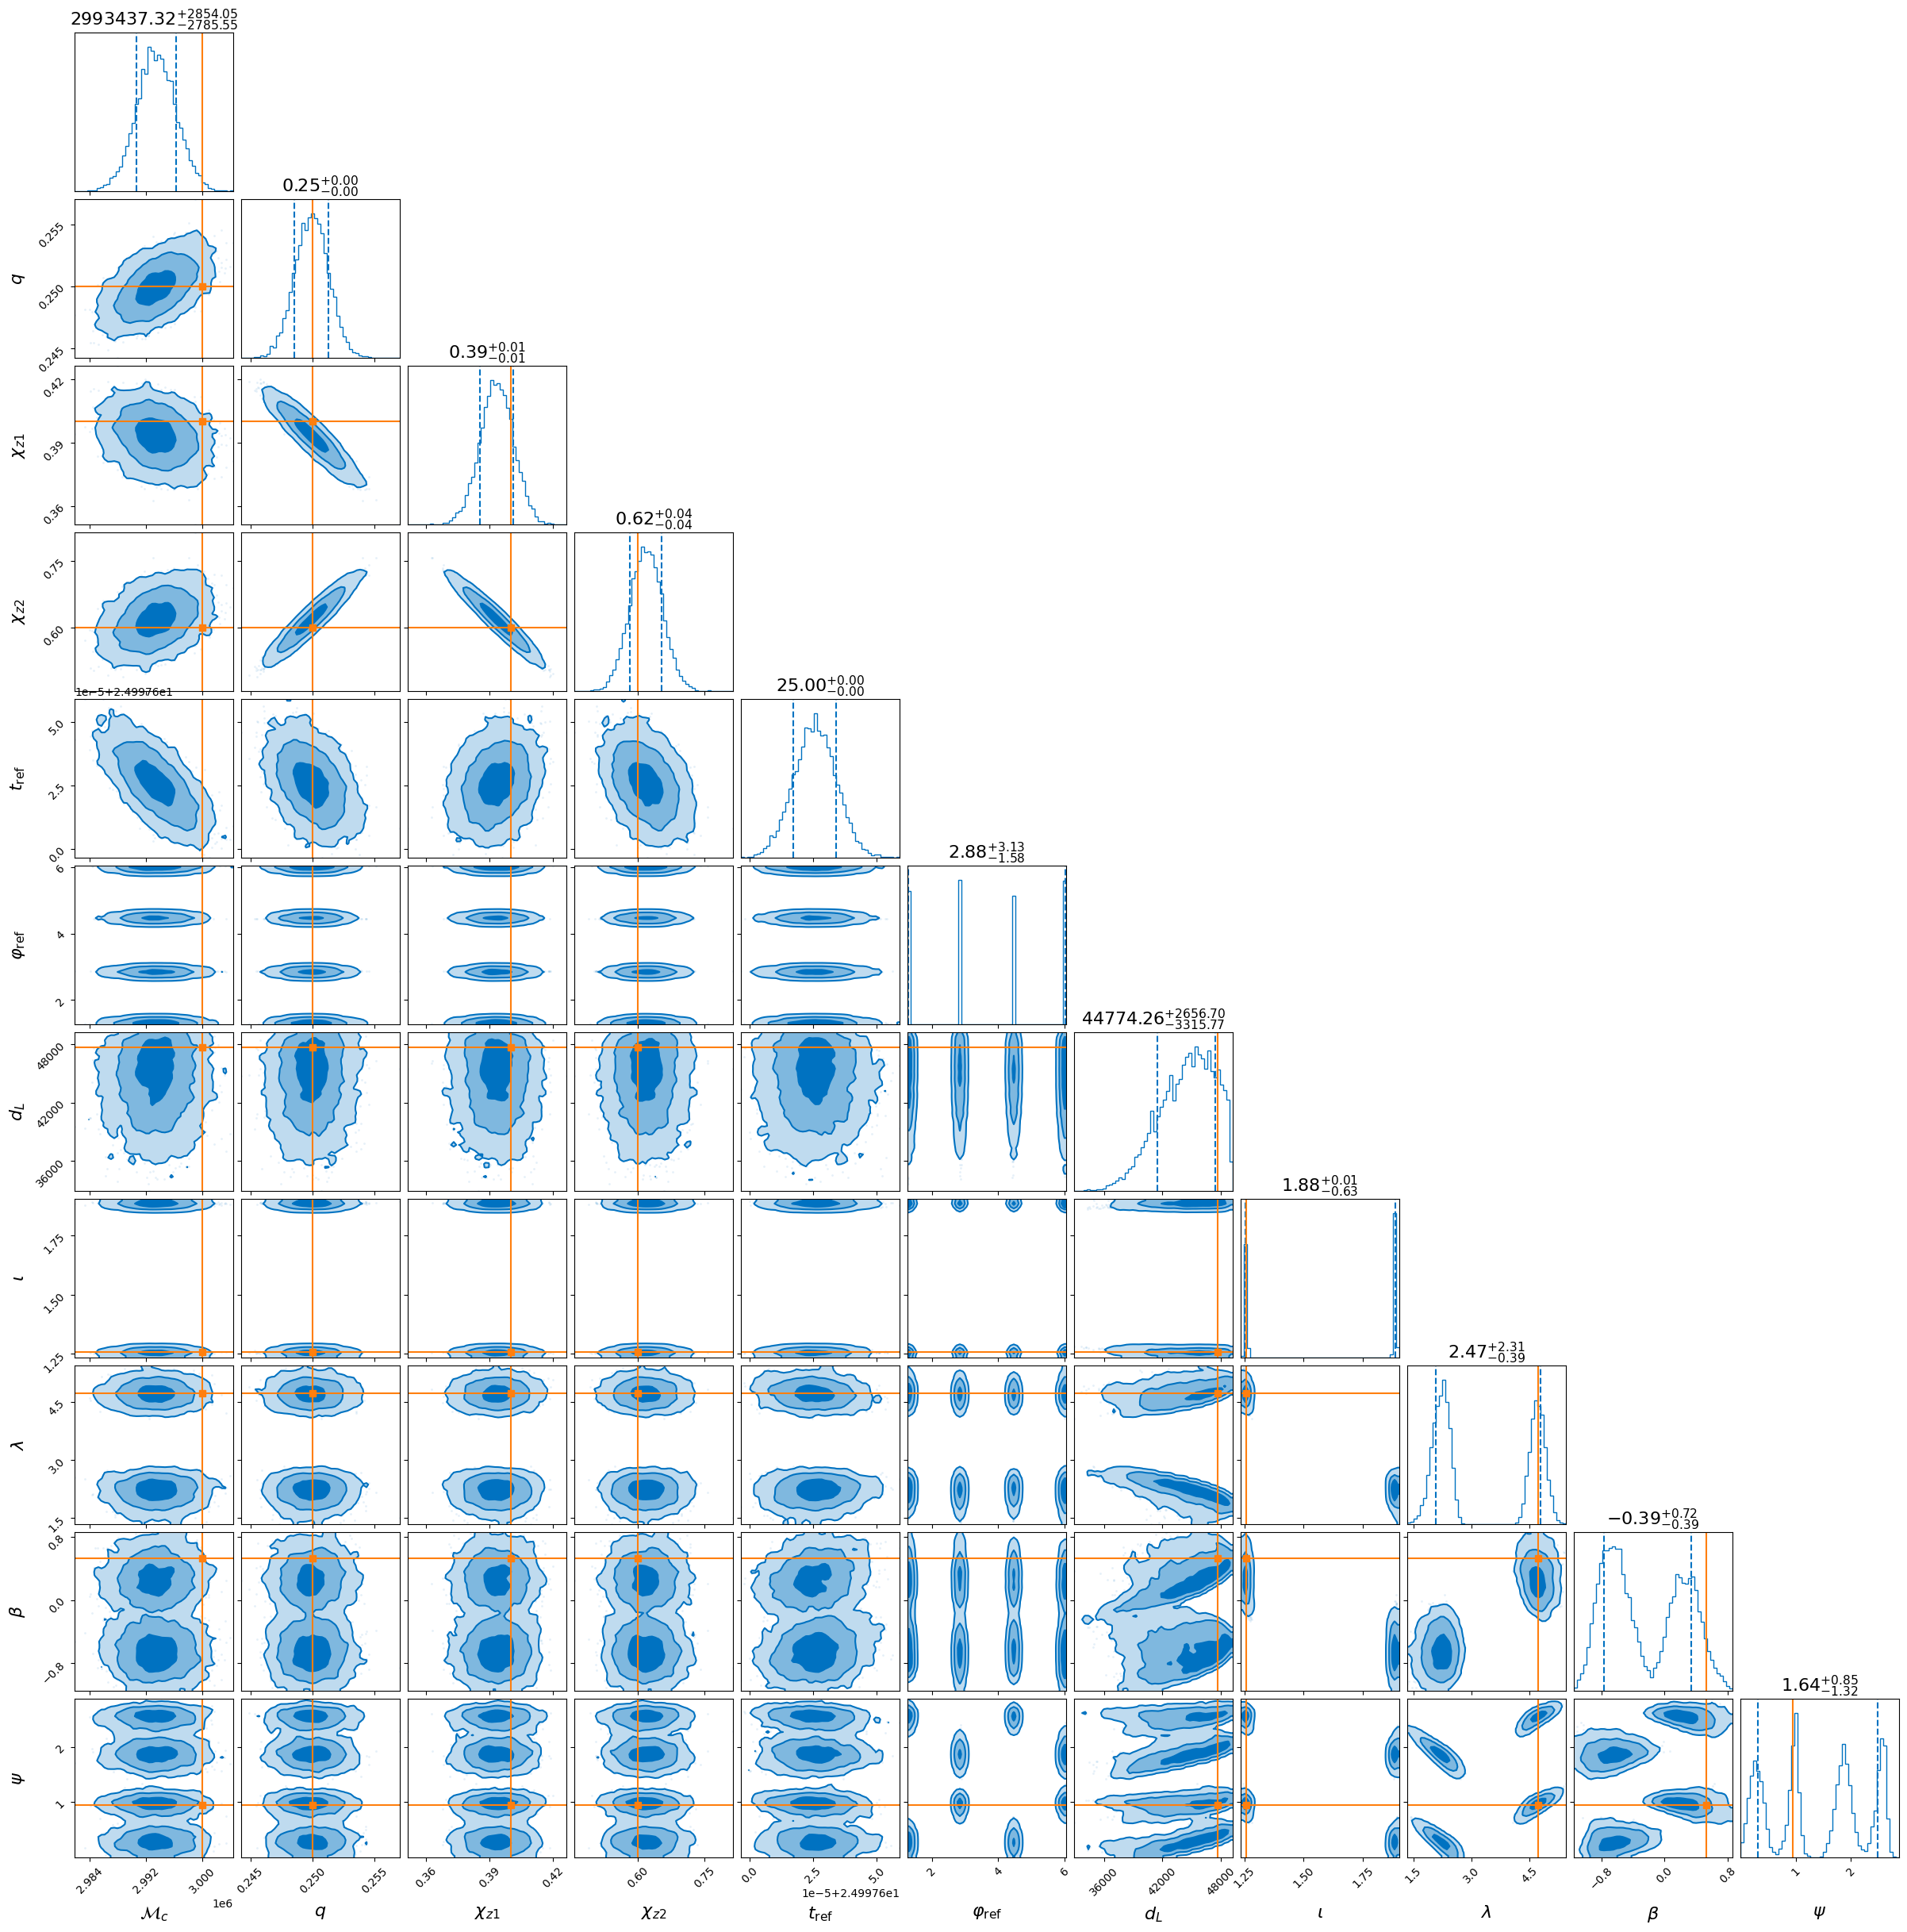

In [22]:
result.plot_corner(save=True)